# Travail sur le challenge kaggle kernel methods

## Rayane Dakhlaoui - Alexandre Mallez

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve as scipy_solve
from scipy.cluster.vq import kmeans2
from numpy.linalg import svd
from scipy.stats import entropy

import cvxopt
import cvxopt.solvers
cvxopt.solvers.options['show_progress'] = False
CVXOPT_OK = True

### Extraction de donnée

In [ ]:
Xtr = np.array(pd.read_csv('Xtr.csv',header=None,sep=',',usecols=range(3072))) 
Xte = np.array(pd.read_csv('Xte.csv',header=None,sep=',',usecols=range(3072))) 
Ytr = np.array(pd.read_csv('Ytr.csv',sep=',',usecols=[1])).squeeze()

In [12]:
print(f"Xtr : {Xtr.shape},  Xte : {Xte.shape},  Ytr : {Ytr.shape}")
print(f"Classes : {np.unique(Ytr)}  — distribution : {np.bincount(Ytr)}")

Xtr : (5000, 3072),  Xte : (2000, 3072),  Ytr : (5000,)
Classes : [0 1 2 3 4 5 6 7 8 9]  — distribution : [500 500 500 500 500 500 500 500 500 500]


### Visualisation

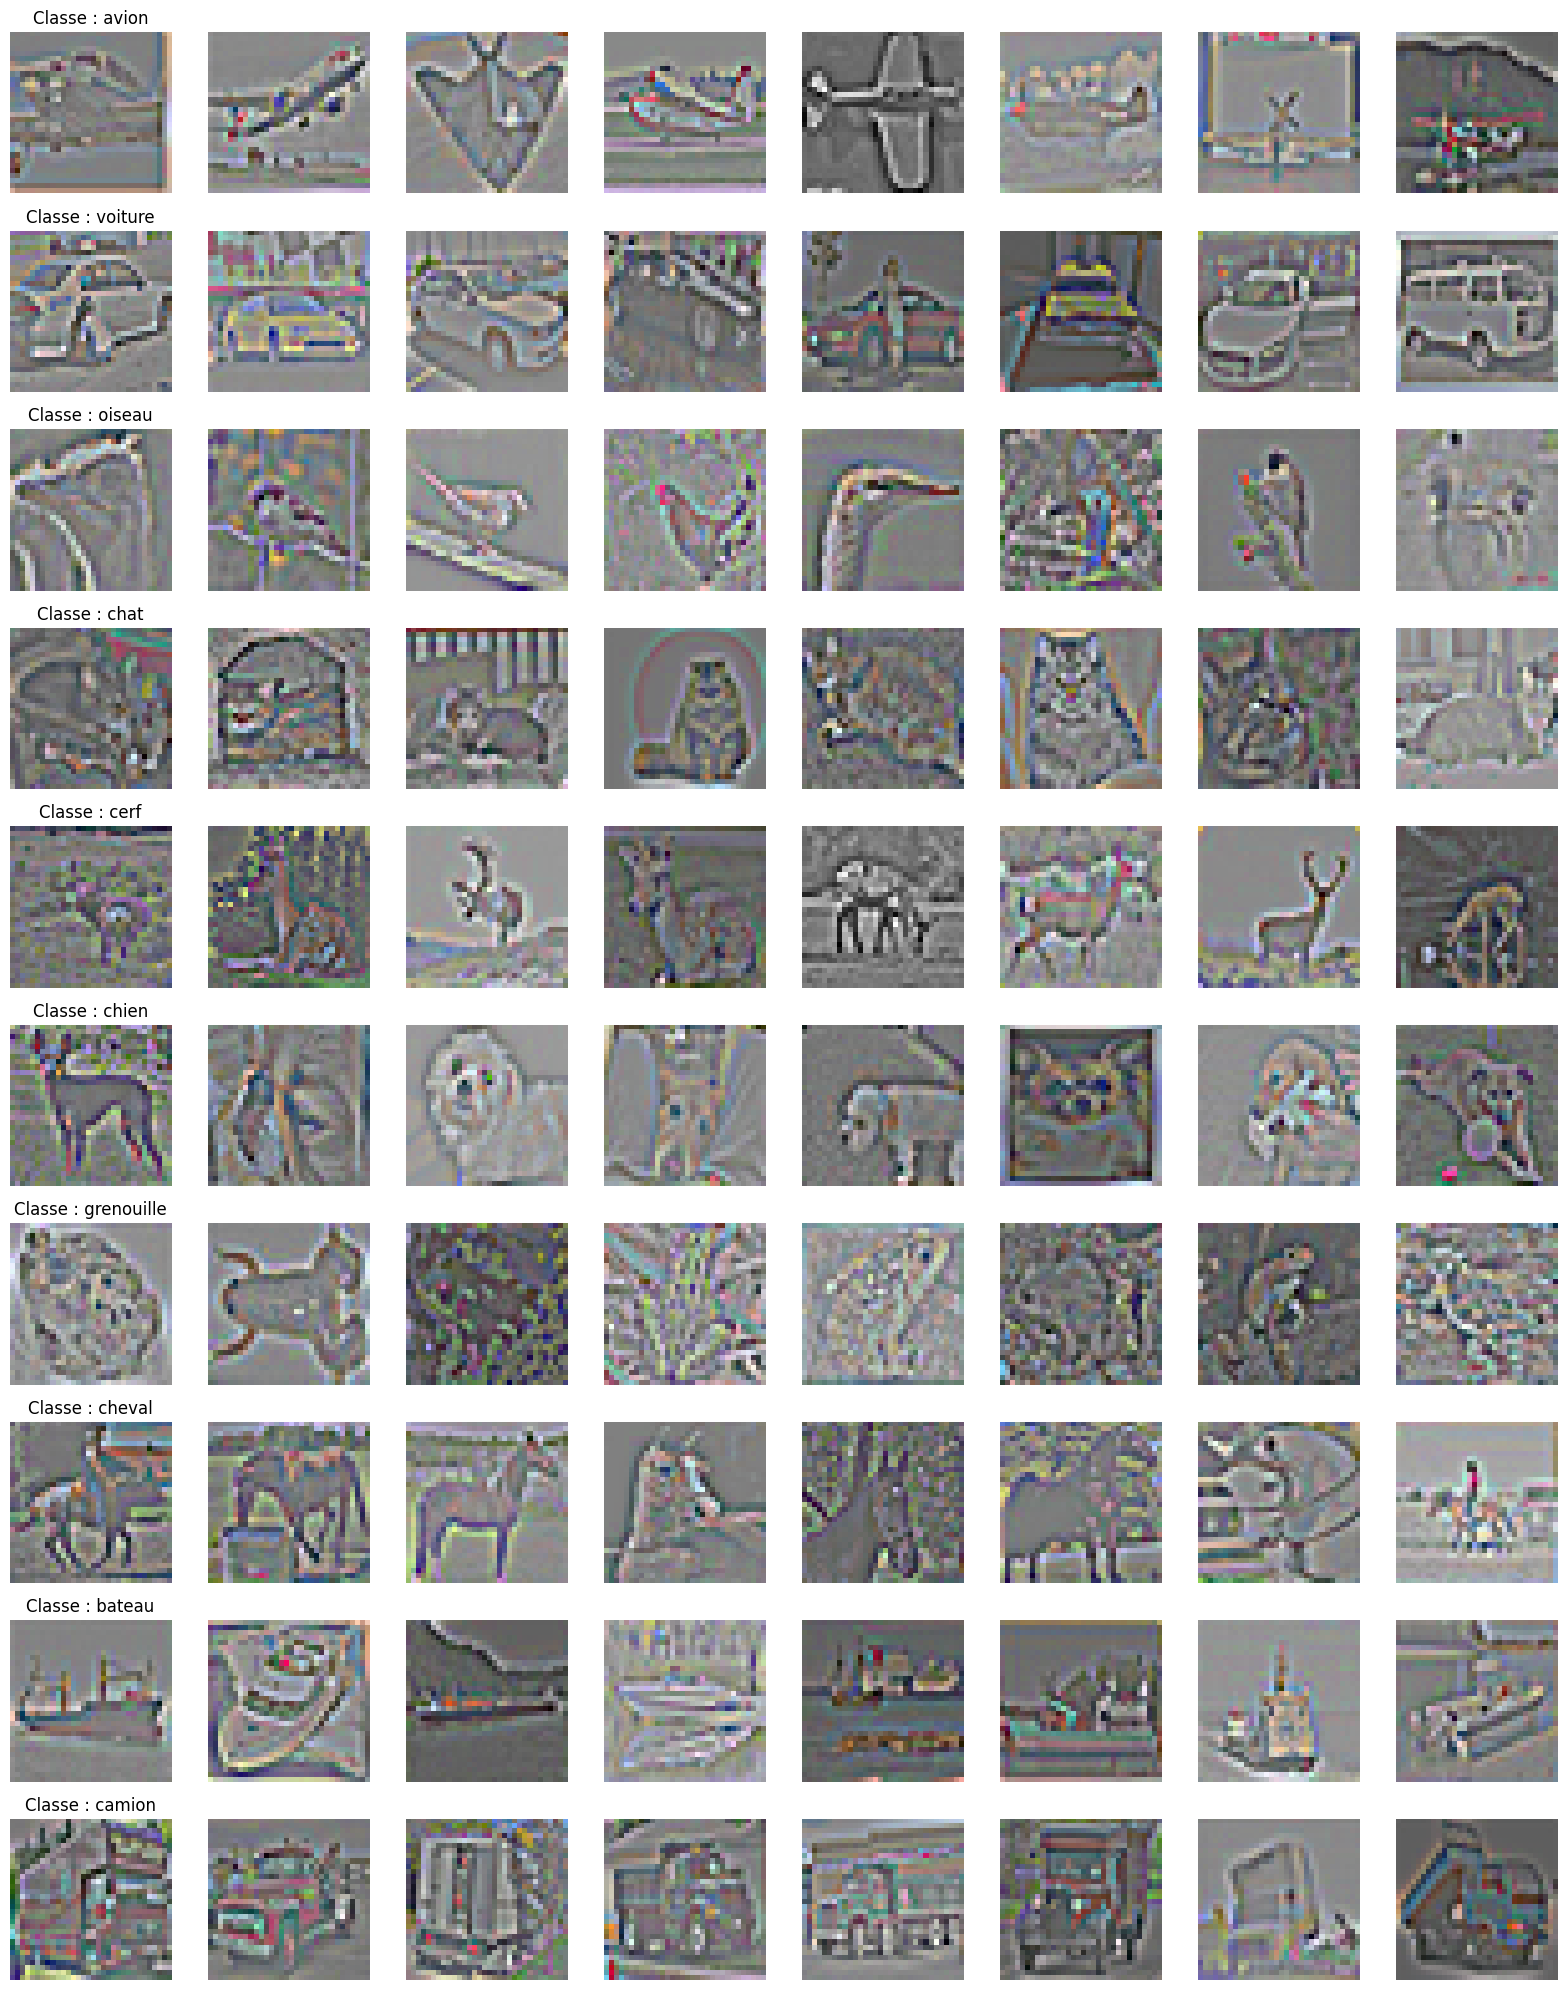

In [13]:
labels = {0:'avion', 1:'voiture', 2:'oiseau', 3:'chat',
                 4:'cerf',  5:'chien',   6:'grenouille',
                 7:'cheval', 8:'bateau', 9:'camion'}

def to_hwc(X_flat):
    """(N, 3072) layout R…R G…G B…B  →  (N, 32, 32, 3)  float64"""
    N = X_flat.shape[0]
    imgs = X_flat.reshape(N, 3, 32, 32).transpose(0, 2, 3, 1)
    return imgs


imgs = to_hwc(Xtr)
n_classes = 10

fig, axes = plt.subplots(n_classes, 8, figsize=(16, n_classes * 2))
for i in range(n_classes):
    idx = np.where(Ytr == i)[0][:8]
    for numj, j in enumerate(idx):
        img_viz = imgs[j]
        img_viz = (img_viz - img_viz.min()) / (img_viz.max() - img_viz.min() + 1e-8)
        axes[i, numj].imshow(img_viz)
        axes[i, numj].axis('off')
        if numj == 0:
            axes[i, numj].set_title(f"Classe : {labels[i]}", fontsize=12)
plt.tight_layout()
plt.show()

On observe des datas assez bruité : ici on a déjà pas mal de mauvaise classification

### Fonction utilitaire et augmentation

In [14]:
def train_val_split(X, y, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    tr_idx, va_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_val = max(1, int(len(idx) * val_frac))
        va_idx.extend(idx[:n_val])
        tr_idx.extend(idx[n_val:])
    return (X[tr_idx], y[tr_idx],
            X[va_idx], y[va_idx])

def accuracy_value(y_true, y_pred):
    return (y_true == y_pred).mean()


def augment(X_hwc, y, seed=42, multi=2):
    """
    1. Flip horizontal
    2. Random crop : pad de 4px en reflect, puis crop 32x32 aléatoire
    
    """
    rng = np.random.default_rng(seed)
    N = len(X_hwc)
    out_X, out_y = [X_hwc], [y]

    # flip horizontal 
    flipped = X_hwc[:, :, ::-1, :].copy()
    out_X.append(flipped) 
    out_y.append(y)

    # random crop (pad 4, crop 32x32) 
    pad = 4
    padded = np.pad(X_hwc, ((0,0),(pad,pad),(pad,pad),(0,0)), mode='reflect')
    crops = np.empty_like(X_hwc)
    for i in range(N):
        r = rng.integers(0, 2*pad)
        c = rng.integers(0, 2*pad)
        crops[i] = padded[i, r:r+32, c:c+32, :]
    out_X.append(crops)
    out_y.append(y)

    X_aug = np.concatenate(out_X, axis=0)
    y_aug = np.concatenate(out_y, axis=0)

    indices = np.random.choice(len(X_aug), N * multi, replace=False)

    return X_aug[indices], y_aug[indices]


#  Vérification rapide 
X_hwc_tr = to_hwc(Xtr)
print(f"Shape HWC train : {X_hwc_tr.shape}")
X_tr_aug, y_tr_aug = augment(X_hwc_tr[:10], Ytr[:10])
print(f"Après augmentation (10→) : {X_tr_aug.shape}")


Shape HWC train : (5000, 32, 32, 3)
Après augmentation (10→) : (20, 32, 32, 3)


---

## Première approche : SVM 

Introduction de différents kernels 

In [17]:

def linear_kernel(X, Y):
    return X @ Y.T


def rbf_kernel(X, Y, gamma=None):
    """
    K(x,y) = exp(-γ ||x-y||²)
    """
    if gamma is None:
        # gamma = 1.0 / X.shape[1]
        gamma = 1.0 / (X.shape[1] * X.var()) # meilleur generalement
    XX = np.einsum('ij,ij->i', X, X)[:, None]
    YY = np.einsum('ij,ij->i', Y, Y)[None, :]
    D2 = XX + YY - 2.0 * (X @ Y.T)
    np.maximum(D2, 0.0, out=D2)
    return np.exp(-gamma * D2)


def chi2_kernel(X, Y, gamma=1.0):
    """
    K(x,y) = exp(-γ Σ_k (x_k - y_k)² / (|x_k| + |y_k| + ε))
    """
    N, M = len(X), len(Y)
    K = np.empty((N, M), dtype=np.float64)
    for i in range(N):
        diff  = X[i] - Y
        denom = np.abs(X[i]) + np.abs(Y) + 1e-10
        dist  = np.sum(diff * diff / denom, axis=1)
        np.clip(dist, 0.0, 500.0 / gamma, out=dist)  # évite exp(-∞) et overflow
        K[i]  = np.exp(-gamma * dist)
    return K


def histogram_intersection_kernel(X, Y):
    """
    K(x,y) = Σ_k min(x_k, y_k)
    """
    N, M = len(X), len(Y)
    K = np.empty((N, M), dtype=np.float64)
    for i in range(N):
        K[i] = np.sum(np.minimum(X[i], Y), axis=1)
    return K


def polynomial_kernel(X, Y, degree=3, coef0=1.0, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    return (gamma * (X @ Y.T) + coef0) ** degree


def combine_kernels(kernel_list, weights=None):
    if weights is None:
        weights = [1.0 / len(kernel_list)] * len(kernel_list)
    return sum(w * K for w, K in zip(weights, kernel_list))


def feat_standardize(X_tr, X_te=None):
    """Normalise colonnes (mean=0, std=1). Fit sur train uniquement."""
    mu  = X_tr.mean(axis=0)
    sig = X_tr.std(axis=0) + 1e-8
    X_tr_sc = (X_tr - mu) / sig
    if X_te is not None:
        return X_tr_sc, (X_te - mu) / sig
    return X_tr_sc


def l2_normalize_rows(X):
    """||x||₂ = 1 par ligne"""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, 1e-8)


# ── Sanity-checks ────────────────────────────────────────────
_X = np.abs(np.random.randn(30, 20))
_K = chi2_kernel(_X, _X)
assert np.isfinite(_K).all(), "chi2 : NaN/Inf !"
print(f"Chi2  — min eigval : {np.linalg.eigvalsh(_K).min():.2e}  (≥ 0 ?)")
_K2 = rbf_kernel(_X, _X)
print(f"RBF   — min eigval : {np.linalg.eigvalsh(_K2).min():.2e}  (≥ 0 ?)")


Chi2  — min eigval : 9.49e-01  (≥ 0 ?)
RBF   — min eigval : 2.85e-01  (≥ 0 ?)


SVM avec cvxopt : One-vs-All multi-classe :

 Formulation duale du SVM soft-margin :

$$\begin{aligned}
\max_{\alpha} \quad & \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \alpha^T Q \alpha \\
\text{s.t.} \quad & 0 \leq \alpha_i \leq C, \quad \forall i \\
& \sum_{i=1}^{n} \alpha_i y_i = 0 \\
\end{aligned}$$
Où $Q_{ij} = y_i y_j K(x_i, x_j)$

Forme Standard pour cvxopt.qp (Minimisation) :
$$\begin{aligned}
\min_{\alpha} \quad & \frac{1}{2} \alpha^T Q \alpha - \mathbf{1}^T \alpha \\
\text{s.t.} \quad & G\alpha \leq h \\
& A\alpha = b
\end{aligned}$$

Avec :
$q = -\mathbf{1}$ 

$G = \begin{bmatrix} -I \\ I \end{bmatrix}$ 

 $h = \begin{bmatrix} \mathbf{0} \\ \mathbf{C} \end{bmatrix}$
 
 $A = y^{T}$ , $b = 0$


In [18]:

def solve_binary_svm(K, y_bin, C=1.0):
    """
    Résout le dual SVM avec cvxopt pour un problème binaire.

    K     : (N, N) matrice kernel symétrique PSD
    y_bin : (N,)  labels dans {-1, +1}
    C     : hyperparamètre de régularisation (marge souple)

    Retourne : alpha (N,), b (float)
    """
    assert CVXOPT_OK, "cvxopt requis pour le SVM"
    N  = len(y_bin)
    y  = y_bin.astype(np.float64)

    # Q = (y y^T) * K
    Q  = np.outer(y, y) * K

    #  Matrices cvxopt 
    P  = cvxopt.matrix(Q)
    q  = cvxopt.matrix(-np.ones(N))

    # Contraintes boîte : 0 ≤ α_i ≤ C <=>  [-I; I] α ≤ [0; C·1]
    G  = cvxopt.matrix(np.vstack([-np.eye(N), np.eye(N)]))
    h  = cvxopt.matrix(np.hstack([np.zeros(N), C * np.ones(N)]))

    # Contrainte égalité : y^T α = 0
    A  = cvxopt.matrix(y.reshape(1, -1))
    b  = cvxopt.matrix(np.zeros(1))

    sol = cvxopt.solvers.qp(P, q, G, h, A, b)
    if sol['status'] != 'optimal':
        print(f" cvxopt status : {sol['status']}")

    alpha = np.array(sol['x']).ravel()

    # Calcul du biais b 
    decision = (alpha * y) @ K
    sv_mask  = (alpha > 1e-5) & (alpha < C - 1e-5)
    if sv_mask.sum() == 0:
        sv_mask = alpha > 1e-5
    b_val    = float(np.mean(y[sv_mask] - decision[sv_mask]))

    return alpha, b_val


class SVMClassifier:
    """
    One-vs-All multi-classe SVM avec kernel pré-calculé.
    Stocke uniquement les alpha des vecteurs supports + biais.
    """

    def __init__(self, C=1.0):
        self.C       = C
        self.alphas_ = {}   # class → alpha (N,)
        self.biases_ = {}   # class → float
        self.classes_ = None

    def fit(self, K_tr, y_tr):
        """
        K_tr : (N, N) kernel matrix pré-calculée
        y_tr : (N,)  labels 0..9
        """
        self.classes_ = np.unique(y_tr)
        self.y_tr_    = y_tr
        for c in self.classes_:
            print(f"  SVM classe {c} vs rest ...", end='\r')
            y_bin = np.where(y_tr == c, 1.0, -1.0)
            alpha, b = solve_binary_svm(K_tr, y_bin, C=self.C)
            self.alphas_[c] = alpha
            self.biases_[c] = b
        print("\nFit SVM terminé.")
        return self

    def predict(self, K_te):
        """
        K_te : (N_te, N_tr) kernel matrix testxtrain
        Retourne : (N_te,) labels prédits
        """
        scores = np.column_stack([
            K_te @ (self.alphas_[c] * np.where(self.y_tr_ == c, 1.0, -1.0))
            + self.biases_[c]
            for c in self.classes_
        ])
        return self.classes_[np.argmax(scores, axis=1)]

    def score(self, K_te, y_te):
        return np.mean(self.predict(K_te) == y_te)


In [ ]:
X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=42)

model = SVMClassifier(C=10.0)
K_tr = rbf_kernel(X_train, X_train)
model.fit(K_tr, Y_train)
K_va = rbf_kernel(X_val, X_train)
Y_pred = model.predict(K_va)
print(f'Accuracy : {accuracy_value(Y_val, Y_pred)}')


  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy : 0.252


Utiliser le SVM sur les datas bruts donnent une mauvaise accuracy, ce qui est prévisibles pour des images, nous devons en amont obtenir des meilleurs features pour nos images.

---

## 2nd approche : implémentation de HOG avant le SVM

Rappel théorique :
 - Gradient par canal, on garde le canal avec la magnitude maximale pour chaque pixel.
 - Histogramme d'orientations non-signées [0,pi) sur chaque cell,
    avec soft-binning bilinéaire pondéré par la magnitude.
 - Normalisation L2-Hys par block (normalise, clip à 0.2, renormalise)
    → invariance aux variations douces de contraste et d'éclairage.

In [19]:

def hog_single(img, orientations=9, ppc=(4, 4), cpb=(2, 2)):
    """
    img       : (H, W, C) float, valeurs quelconques
    orientations : nb de bins angulaires
    ppc       : (cy, cx) pixels par cell
    cpb       : (by, bx) cells par block

    Retourne un vecteur 1D.
    Pour 32x32, ppc=(4,4), cpb=(2,2) :
      grid 8x8 cells → 7x7 blocks → 7*7*2*2*9 = 1764 features
    """
    H, W, C = img.shape
    cy, cx = ppc
    by, bx = cpb

    #  1. Gradients, max-magnitude sur les canaux ─
    Gx = np.zeros((H, W))
    Gy = np.zeros((H, W))
    mag_best = np.zeros((H, W))

    for c in range(C):
        ch = img[:, :, c].astype(np.float64)
        # différences centrales avec bords simples
        gx = np.empty_like(ch)
        gy = np.empty_like(ch)

        gx[:, 1:-1] = ch[:, 2:] - ch[:, :-2]
        gx[:, 0]    = 0.0  
        gx[:, -1]   = 0.0   
        gy[1:-1, :] = ch[2:, :] - ch[:-2, :]
        gy[0, :]    = 0.0
        gy[-1, :]   = 0.0

        mag = np.hypot(gx, gy)
        mask = mag > mag_best
        Gx[mask] = gx[mask]
        Gy[mask] = gy[mask]
        mag_best[mask] = mag[mask]

    # 2. Orientation non-signée [0, pi) 
    angle = np.arctan2(Gy, Gx) % np.pi   # [0, pi)

    # 3. Cell histograms — soft-binning bilinéaire 
    n_cy = H // cy
    n_cx = W // cx
    bin_w = np.pi / orientations

    # Pour chaque pixel : bin flottant, bin bas et haut + poids
    bin_f  = angle / bin_w - 0.5          # bin "continu"
    bin_lo = np.floor(bin_f).astype(int) % orientations
    bin_hi = (bin_lo + 1) % orientations
    w_hi   = bin_f - np.floor(bin_f)
    w_lo   = 1.0 - w_hi

    cells = np.zeros((n_cy, n_cx, orientations))
    for i in range(n_cy):
        for j in range(n_cx):
            sl = np.s_[i*cy:(i+1)*cy, j*cx:(j+1)*cx]
            m  = mag_best[sl].ravel()
            bl = bin_lo[sl].ravel()
            bh = bin_hi[sl].ravel()
            wl = w_lo[sl].ravel()
            wh = w_hi[sl].ravel()
            np.add.at(cells[i, j], bl, m * wl)
            np.add.at(cells[i, j], bh, m * wh)

    #  Block normalization L2-Hys 
    n_by = n_cy - by + 1
    n_bx = n_cx - bx + 1
    feats = []
    for i in range(n_by):
        for j in range(n_bx):
            block = cells[i:i+by, j:j+bx, :].ravel().copy()
            norm  = np.sqrt(block @ block + 1e-5)
            block /= norm
            np.clip(block, 0, 0.2, out=block)
            norm2 = np.sqrt(block @ block + 1e-5)
            feats.append(block / norm2)

    return np.concatenate(feats)

# Test 
_test = hog_single(to_hwc(Xtr)[0])
print(f"HOG feature dim pour 1 image : {_test.shape[0]}")
# Expected: 1764  (7x7 blocks x 4 cells/block x 9 bins)


HOG feature dim pour 1 image : 1764


In [20]:
def extract_hog(X_hwc, orientations=9, ppc=(4, 4), cpb=(2, 2)):
    """Applique hog_single sur toute une matrice (N, 32, 32, 3)."""
    features = []
    for img in X_hwc:
        f = hog_single(img, orientations, ppc, cpb)
        features.append(f)
    return np.array(features)

In [54]:
X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=42)

X_tr_hog = extract_hog(to_hwc(X_train))
X_va_hog = extract_hog(to_hwc(X_val))

K_tr = rbf_kernel(X_tr_hog, X_tr_hog)
K_va = rbf_kernel(X_va_hog, X_tr_hog)

for C in [0.1, 1.0, 10.0, 20.0]:
    model = SVMClassifier(C=C)
    model.fit(K_tr, Y_train)
    Y_pred = model.predict(K_va)
    print(f'Accuracy with C={C} : {accuracy_value(Y_val, Y_pred)}')

  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy with C=0.1 : 0.549
  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy with C=1.0 : 0.561
  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy with C=10.0 : 0.567
  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy with C=20.0 : 0.567


On obtient des biens meilleurs résultats, on peut essayer de faire de la data augmentation pour améliorer encore un peu.

On garde la valeur C=20

In [ ]:
X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=42)
X_train, Y_train = augment(to_hwc(X_train), Y_train, seed=42, multi=2)

X_tr_hog = extract_hog(X_train)
X_va_hog = extract_hog(to_hwc(X_val))

K_tr = rbf_kernel(X_tr_hog, X_tr_hog)
K_va = rbf_kernel(X_va_hog, X_tr_hog)


model = SVMClassifier(C=20.)
model.fit(K_tr, Y_train)
Y_pred = model.predict(K_va)

print(f'Accuracy with C=20 : {accuracy_value(Y_val, Y_pred)}')

  SVM classe 9 vs rest ...
Fit SVM terminé.
Accuracy with C=20.0 : 0.594


On voit que ça a augmenté un petit peu, cependant le SVM prends beaucoup plus de temps à s'executer.

On note aussi qu'on a essayé avec notre noyau mais que le rbf restait consistamment le meilleur.

---

## 3ème approche : HOG avec Kernel Ridge Regression

Décomposition spectrale de $K$ (une seule fois par fold) :
$$K = Q \Lambda Q^T \implies O(N^3)$$
Inversion pour tout $\lambda$ :
$$(K + \lambda I)^{-1} = Q (\Lambda + \lambda I)^{-1} Q^T$$

In [21]:

def one_hot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


class KernelRidgeClassifier:
    def __init__(self, lam=1.0, kernel_fn=None, **kernel_kwargs):
        self.lam           = lam
        self.kernel_fn     = kernel_fn if kernel_fn is not None else rbf_kernel
        self.kernel_kwargs = kernel_kwargs

    def fit(self, X_tr, y_tr):
        self.X_tr_ = X_tr
        K = self.kernel_fn(X_tr, X_tr, **self.kernel_kwargs)
        K += self.lam * np.eye(len(X_tr))
        Y = one_hot(y_tr)
        self.alpha_ = scipy_solve(K, Y, assume_a='pos')
        return self

    def decision_function(self, X_te):
        K_te = self.kernel_fn(X_te, self.X_tr_, **self.kernel_kwargs)
        return K_te @ self.alpha_

    def predict(self, X_te):
        return np.argmax(self.decision_function(X_te), axis=1)

    def score(self, X_te, y_te):
        return np.mean(self.predict(X_te) == y_te)


In [56]:
X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=42)
X_train, Y_train = augment(to_hwc(X_train), Y_train, seed=42, multi=3)

X_tr_hog = extract_hog(X_train)
X_va_hog = extract_hog(to_hwc(X_val))

X_tr_hog_l2 = l2_normalize_rows(X_tr_hog)
X_va_hog_l2 = l2_normalize_rows(X_va_hog)

for lamb in [0.05, 0.1, 0.5, 1.0]:
    model = KernelRidgeClassifier(lam=lamb, kernel_fn=rbf_kernel)
    model.fit(X_tr_hog_l2, Y_train)
    Y_pred = model.predict(X_va_hog_l2)
    print(f'Accuracy with λ={lamb} : {accuracy_value(Y_val, Y_pred)}')


Accuracy with λ=0.05 : 0.619
Accuracy with λ=0.1 : 0.619
Accuracy with λ=0.5 : 0.603
Accuracy with λ=1.0 : 0.595


Les résultats sont un peu mieux qu'avec le SVM

---

## 4ème approche : CKN avant PCA et KRR

L'initialisation utilise un k-mean donc on code la fonction

In [22]:
# Meilleur initialisation du kmeans pour que les filtres soient plus variés que des duplicates aléatoires
def kmeans_plus_plus_init(X, k, rng):
    idx = rng.integers(len(X))
    centers = [X[idx]]
    min_dists = np.full(len(X), np.inf, dtype=np.float32)
    
    for _ in range(k - 1):
        c = centers[-1]  # dernier centre ajouté
        
        # Distance au dernier centre seulement 
        diff = X - c
        new_dists = (diff ** 2).sum(axis=1)
        
        # Mise à jour du minimum
        min_dists = np.minimum(min_dists, new_dists)
        
        # Tirage proportionnel
        probs = min_dists / min_dists.sum()
        idx = rng.choice(len(X), p=probs)
        centers.append(X[idx])
    
    return np.stack(centers)

In [23]:
def kmeans_scratch(X, k, n_iter=30, seed=42, verbose=True):
    """
    K-means from scratch.
    X : (N, d) float32
    Returns: centers (k, d)
    """
    rng = np.random.default_rng(seed)
    
    centers = kmeans_plus_plus_init(X, k, rng)
    
    for it in range(n_iter):
        # Assignation : distance euclidienne au carré
        # ||x - c||^2 = ||x||^2 + ||c||^2 - 2 x·c
        X_sq    = (X ** 2).sum(axis=1, keepdims=True)      # (N, 1)
        C_sq    = (centers ** 2).sum(axis=1, keepdims=True) # (k, 1)
        dots    = X @ centers.T                              # (N, k)
        dists   = X_sq + C_sq.T - 2 * dots                  # (N, k)
        labels  = dists.argmin(axis=1)                       # (N,)
        
        # Mise à jour des centres
        new_centers = np.zeros_like(centers)
        for j in range(k):
            mask = labels == j
            if mask.sum() == 0:
                # Cluster vide : réinitialiser aléatoirement
                new_centers[j] = X[rng.integers(len(X))]
            else:
                new_centers[j] = X[mask].mean(axis=0)
        
        # Convergence
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        
        if verbose:
            print(f"  iter {it+1}/{n_iter} — shift: {shift:.6f}")
        if shift < 1e-6:
            print(f"  Convergence atteinte à l'itération {it+1}")
            break
    
    return centers

Convolutional Kernel Network — random filters (no training).

Pipeline per image:
  1. Extract 3x3 patches on a grid
  2. ZCA whitening on patches
  3. L2-normalize each patch
  4. Arc-cosine kernel approximation: ReLU(patches @ filters)
  5. Average pooling with subsampling
  6. Spatial Pyramid Matching (SPM) for multi-scale pooling
  7. Power-norm + L2-normalize the final feature vector

In [24]:

# Patch extraction 

def _extract_patches_raw(img, patch_size):
    """
    img : (H, W, C)
    Returns: (n_h, n_w, patch_size*patch_size*C)
    """
    H, W, C = img.shape
    p = patch_size
    n_h = H - p + 1
    n_w = W - p + 1
    patches = np.empty((n_h, n_w, p * p * C), dtype=np.float32)
    for r in range(n_h):
        for c in range(n_w):
            patches[r, c] = img[r:r+p, c:c+p, :].ravel()
    return patches


# Random filters 
def make_random_filters(patch_size, n_channels=3, n_filters=256, seed=42):
    """
    Random Gaussian filters, L2-normalized.
    Returns: (n_filters, patch_size*patch_size*n_channels)
    """
    rng = np.random.default_rng(seed)
    d = patch_size * patch_size * n_channels
    W = rng.standard_normal((n_filters, d)).astype(np.float32)
    W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-8
    return W


#  K-means filters 

def make_kmeans_filters(X, patch_size=3, n_filters=256,
                        patch_mean=None, W_zca=None,
                        n_subsample=200000, seed=42, verbose=True):
    """
    Learn filters via k-means on whitened, L2-normalized patches.
    Returns: (n_filters, patch_dim)
    """

    if verbose:
        print("  K-means filters: collecting patches...")
    rng = np.random.default_rng(seed)
    N = X.shape[0]

    all_patches = []
    for i in range(N):
        img = X[i].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.float32)
        if img.max() > 1.5:
            img = img / 255.0
        patches = _extract_patches_raw(img, patch_size)
        all_patches.append(patches.reshape(-1, patches.shape[-1]))

    all_patches = np.concatenate(all_patches, axis=0)

    if len(all_patches) > n_subsample:
        idx = rng.choice(len(all_patches), n_subsample, replace=False)
        all_patches = all_patches[idx]

    # whiten
    if patch_mean is not None and W_zca is not None:
        all_patches = (all_patches - patch_mean) @ W_zca.T

    # L2-normalize
    norms = np.linalg.norm(all_patches, axis=1, keepdims=True)
    all_patches = all_patches / (norms + 1e-8)

    if verbose:
        print(f"  K-means on {len(all_patches)} patches -> {n_filters} clusters...")
    centers = kmeans_scratch(all_patches.astype(np.float32), k=n_filters,
                         n_iter=30, seed=seed, verbose=verbose)

    # L2-normalize centers
    centers = centers / (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-8)
    if verbose:
        print(f"  K-means filters ready: {centers.shape}")
    return centers.astype(np.float32)


#  ZCA whitening 

def fit_patch_whitening(X, patch_size=3, reg=1e-3, n_subsample=200000, seed=42):
    """
    Fit ZCA whitening on a subsample of patches from X.
    X : (N, 3072) flat images
    Returns: patch_mean (d,), W_zca (d, d)
    """
    rng = np.random.default_rng(seed)
    N = X.shape[0]
    # collect patches
    all_patches = []
    for i in range(N):
        img = X[i].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.float32)
        if img.max() > 1.5:
            img = img / 255.0
        patches = _extract_patches_raw(img, patch_size)
        all_patches.append(patches.reshape(-1, patches.shape[-1]))

    all_patches = np.concatenate(all_patches, axis=0)

    if len(all_patches) > n_subsample:
        idx = rng.choice(len(all_patches), n_subsample, replace=False)
        all_patches = all_patches[idx]

    patch_mean = all_patches.mean(axis=0)
    centered = all_patches - patch_mean

    cov = (centered.T @ centered) / len(centered)
    U, S, _ = np.linalg.svd(cov)
    W_zca = U @ np.diag(1.0 / np.sqrt(S + reg)) @ U.T
    W_zca = W_zca.astype(np.float32)

    return patch_mean, W_zca


#  Average/max pooling 

def spatial_pool(Z, subsampling, mode='avg'):
    """
    Z : (H, W, C)
    Pool with stride = subsampling.
    mode: 'avg' for average pooling, 'max' for max pooling
    Returns: (H', W', C)
    """
    H, W, C = Z.shape
    s = subsampling
    n_h = H // s
    n_w = W // s
    Z_cut = Z[:n_h * s, :n_w * s, :]
    blocks = Z_cut.reshape(n_h, s, n_w, s, C)
    if mode == 'max':
        return blocks.max(axis=(1, 3))
    return blocks.mean(axis=(1, 3))


# SPM features

def ckn_spm_features(feat_map, levels=(1, 2, 4)):
    """
    Spatial Pyramid Matching on a feature map.
    feat_map : (H, W, n_filters)
    levels : tuple of grid sizes (e.g. 1x1, 2x2, 4x4)
    Returns: concatenated feature vector
    """
    H, W, C = feat_map.shape
    parts = []
    for L in levels:
        bh = max(1, H // L)
        bw = max(1, W // L)
        for i in range(L):
            for j in range(L):
                r0, r1 = i * bh, min((i + 1) * bh, H)
                c0, c1 = j * bw, min((j + 1) * bw, W)
                block = feat_map[r0:r1, c0:c1, :]
                parts.append(block.mean(axis=(0, 1)))
    return np.concatenate(parts)


# Single image CKN layer

def ckn_layer(img, filters, patch_size=3,
              subsampling=2, pool_mode='avg',
              patch_mean=None, W_zca=None):
    """
    Apply one CKN layer to a single (H, W, C) image.

    Returns: feature_map (H', W', n_filters)
    """
    # 1 — Extract patches
    patches = _extract_patches_raw(img, patch_size)
    ph, pw = patches.shape[:2]
    flat = patches.reshape(-1, patches.shape[2])        # (ph*pw, d)

    # 2 — ZCA whitening (if fitted)
    if patch_mean is not None and W_zca is not None:
        flat = (flat - patch_mean) @ W_zca.T

    # 3 — L2-normalise each patch vector
    norms = np.linalg.norm(flat, axis=1, keepdims=True)
    flat = flat / (norms + 1e-8)

    # 4 — Arc-cosine kernel approximation: ReLU(patches @ W)
    Z = np.maximum(flat @ filters.T, 0)                 # (ph*pw, n_filters)
    Z = Z.reshape(ph, pw, -1)                            # (ph, pw, n_filters)

    # 5 — Spatial pooling
    return spatial_pool(Z, subsampling, mode=pool_mode)  # (H', W', n_filters)


# Full feature extraction using CKN

def extract_ckn_features(X, patch_size=3, n_filters=256,
                         subsampling=2, pool_mode='avg',
                         levels=(1, 2, 4),
                         use_whitening=True, whitening_reg=1e-3,
                         use_kmeans=False,
                         normalize='l2',
                         patch_mean=None, W_zca=None,
                         filters=None,
                         return_whitening=False,
                         seed=42, verbose=True):
    """
    Extract CKN features for a dataset.

    X : (N, 3072) flat images
    Returns: F (N, feat_dim) or (F, patch_mean, W_zca) if return_whitening
    """
    # Whitening
    if patch_mean is not None and W_zca is not None:
        pass  # pre-fitted (test set path)
    elif use_whitening:
        if verbose:
            print("  Fitting ZCA patch whitening on training patches...")
        patch_mean, W_zca = fit_patch_whitening(
            X, patch_size=patch_size, reg=whitening_reg, seed=seed)
    else:
        patch_mean, W_zca = None, None

    # Filters
    if filters is not None:
        pass  # pre-computed (test set path)
    elif use_kmeans:
        filters = make_kmeans_filters(X, patch_size=patch_size,
                                      n_filters=n_filters,
                                      patch_mean=patch_mean, W_zca=W_zca,
                                      seed=seed, verbose=verbose)
    else:
        filters = make_random_filters(patch_size, n_channels=3,
                                      n_filters=n_filters, seed=seed)

    N = X.shape[0]
    features = []

    for i in range(N):
        if verbose and i % 500 == 0:
            print(f"  CKN features: {i}/{N}")

        img = X[i].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.float32)
        img = img / 255.0 if img.max() > 1.5 else img

        feat_map = ckn_layer(img, filters,
                             patch_size=patch_size,
                             subsampling=subsampling,
                             pool_mode=pool_mode,
                             patch_mean=patch_mean,
                             W_zca=W_zca)
        feat = ckn_spm_features(feat_map, levels=levels)
        features.append(feat)

    F = np.stack(features)

    if normalize == 'l2':
        F = np.sign(F) * np.sqrt(np.abs(F))
        F /= np.linalg.norm(F, axis=1, keepdims=True) + 1e-8

    F = F.astype(np.float32)

    if return_whitening:
        return F, patch_mean, W_zca, filters
    return F


PCA car le CKN donne beaucoup de features

In [25]:
def pca_analysis(F, title="PCA", verbose=False):
    """Print variance thresholds + effective rank."""
    mean = F.mean(axis=0)
    _, s, Vt = svd(F - mean, full_matrices=False)
    var_ratio = (s**2) / (s**2).sum()
    cum_var = np.cumsum(var_ratio)

    if verbose:
        print(f"\n--- {title} diagnostic ---")
        for thresh in [0.90, 0.95, 0.99]:
            d = np.searchsorted(cum_var, thresh) + 1
            print(f"  {thresh*100:.0f}% variance -> {d} components (out of {len(s)})")

    p = (s**2) / (s**2).sum()
    eff_rank = np.exp(entropy(p))
    if verbose:
        print(f"  Effective rank: {eff_rank:.1f} / {len(s)}")
    return mean, s, Vt


def pca_project(F_tr, F_te, mean, Vt, n_components):
    """Project onto top PCA components."""
    Vt_d = Vt[:n_components]
    return (F_tr - mean) @ Vt_d.T, (F_te - mean) @ Vt_d.T

In [26]:
SEED = 1
np.random.seed(SEED)

X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=SEED)

In [27]:

F_train, patch_mean, W_zca, filters = extract_ckn_features(
    X_train,
    patch_size=3,        # taille des patches (3x3)
    n_filters=256,       # nombre de filtres aléatoires
    subsampling=2,       # facteur de sous-échantillonnage spatial
    pool_mode='avg',     # 'avg' ou 'max'
    levels=(1, 2, 4),   # niveaux de la pyramide spatiale (SPM)
    use_whitening=True,  # ZCA whitening recommandé
    use_kmeans=True,    # False = filtres aléatoires (plus rapide)
    normalize='l2',      # power-norm + L2
    return_whitening=True,  # récupère les paramètres pour le test
    seed = SEED,
    verbose=True

)

  Fitting ZCA patch whitening on training patches...
  K-means filters: collecting patches...
  K-means on 200000 patches -> 256 clusters...
  iter 1/30 — shift: 7.187950
  iter 2/30 — shift: 1.802207
  iter 3/30 — shift: 1.221576
  iter 4/30 — shift: 0.910154
  iter 5/30 — shift: 0.718664
  iter 6/30 — shift: 0.592565
  iter 7/30 — shift: 0.499308
  iter 8/30 — shift: 0.436128
  iter 9/30 — shift: 0.392972
  iter 10/30 — shift: 0.359250
  iter 11/30 — shift: 0.324757
  iter 12/30 — shift: 0.300144
  iter 13/30 — shift: 0.281254
  iter 14/30 — shift: 0.266573
  iter 15/30 — shift: 0.252271
  iter 16/30 — shift: 0.239198
  iter 17/30 — shift: 0.223961
  iter 18/30 — shift: 0.210032
  iter 19/30 — shift: 0.200967
  iter 20/30 — shift: 0.190407
  iter 21/30 — shift: 0.181638
  iter 22/30 — shift: 0.174758
  iter 23/30 — shift: 0.168807
  iter 24/30 — shift: 0.170450
  iter 25/30 — shift: 0.160775
  iter 26/30 — shift: 0.151768
  iter 27/30 — shift: 0.144716
  iter 28/30 — shift: 0.137512


In [ ]:
F_val = extract_ckn_features(
    X_val,
    patch_size=3,
    n_filters=256,
    subsampling=2,
    levels=(1, 2, 4),
    use_whitening=True,
    patch_mean=patch_mean,   # paramètres fitted sur le train
    W_zca=W_zca,             # 
    filters=filters,          # filtres du train
    return_whitening=False,
    seed=SEED,
    verbose=True
)

  CKN features: 0/1000
  CKN features: 500/1000


In [32]:
F_train_sc, F_val_sc = feat_standardize(F_train, F_val)

In [ ]:
pca_mean, pca_s, pca_Vt = pca_analysis(F_train_sc, title="CKN features", verbose=True)
n_comp = 1024
F_train_pca, F_val_pca = pca_project(F_train_sc, F_val_sc, pca_mean, pca_Vt, n_comp)


--- CKN features diagnostic ---
  90% variance -> 267 components (out of 1024)
  95% variance -> 419 components (out of 1024)
  99% variance -> 786 components (out of 1024)
  Effective rank: 168.3 / 1024


In [ ]:
for lamb in [0.01, 0.05, 0.1, 0.5, 1.0]:
    model = KernelRidgeClassifier(lam=lamb, kernel_fn=rbf_kernel)
    model.fit(F_train_pca, Y_train)
    Y_pred = model.predict(F_val_pca)
    print(f"Accuracy with λ={lamb}: {accuracy_value(Y_val, Y_pred):.4f} ")

Accuracy with λ=0.01: 0.6280 
Accuracy with λ=0.05: 0.6280 
Accuracy with λ=0.1: 0.6250 
Accuracy with λ=0.5: 0.6150 
Accuracy with λ=1.0: 0.6080 


L'accuracy est meilleur qu'avec HOG + KRR.

On note qu'on aussi essayer avec SVM mais que les résultats étaient moins bon alors que l'algorithme prenait bien plus de temps à s'executer, on a donc décidé de continuer qu'avec KRR.

---

## 5èeme approche : augmentation, combinaison des features CKN et HOG puis PCA et KRR

Etant donné que le HOG récolte des features de texture et CKN des features plus sémantique, on peut combiner les 2 features pour esperer avoir de meilleurs résultats

In [71]:
SEED = 42
np.random.seed(SEED)

X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=SEED)

X_train, Y_train = augment(to_hwc(X_train), Y_train, seed=SEED, multi=3)
N = X_train.shape[0]
X_train = X_train.transpose(0, 3, 1, 2).reshape(N, 3072)


In [91]:

F_train, patch_mean, W_zca, filters = extract_ckn_features(
    X_train,
    patch_size=3,        # taille des patches (3x3)
    n_filters=512,       # nombre de filtres aléatoires (on a augmenté à 512)
    subsampling=2,       # facteur de sous-échantillonnage spatial
    pool_mode='avg',     # 'avg' ou 'max'
    levels=(1, 2, 4),   # niveaux de la pyramide spatiale (SPM)
    use_whitening=True,  # ZCA whitening recommandé
    use_kmeans=True,    # False = filtres aléatoires (plus rapide)
    normalize='l2',      # power-norm + L2
    return_whitening=True,  # récupère les paramètres pour le test
    seed = SEED,
    verbose=True

)


  Fitting ZCA patch whitening on training patches...
  K-means filters: collecting patches...
  K-means on 200000 patches -> 512 clusters...
  iter 1/30 — shift: 9.424521
  iter 2/30 — shift: 2.465508
  iter 3/30 — shift: 1.677452
  iter 4/30 — shift: 1.262123
  iter 5/30 — shift: 1.007419
  iter 6/30 — shift: 0.839258
  iter 7/30 — shift: 0.714763
  iter 8/30 — shift: 0.628122
  iter 9/30 — shift: 0.564853
  iter 10/30 — shift: 0.503007
  iter 11/30 — shift: 0.455890
  iter 12/30 — shift: 0.421637
  iter 13/30 — shift: 0.397283
  iter 14/30 — shift: 0.371775
  iter 15/30 — shift: 0.349304
  iter 16/30 — shift: 0.333131
  iter 17/30 — shift: 0.313864
  iter 18/30 — shift: 0.295333
  iter 19/30 — shift: 0.272698
  iter 20/30 — shift: 0.265397
  iter 21/30 — shift: 0.256134
  iter 22/30 — shift: 0.241734
  iter 23/30 — shift: 0.231272
  iter 24/30 — shift: 0.221180
  iter 25/30 — shift: 0.211420
  iter 26/30 — shift: 0.198547
  iter 27/30 — shift: 0.192654
  iter 28/30 — shift: 0.184987


In [ ]:
F_val = extract_ckn_features(
    X_val,
    patch_size=3,
    n_filters=512,
    subsampling=2,
    levels=(1, 2, 4),
    use_whitening=True,
    patch_mean=patch_mean,   # ← paramètres fitted sur le train
    W_zca=W_zca,             # ←
    filters=filters,          # ← filtres du train
    return_whitening=False,
    seed=SEED,
    verbose=True
)


  CKN features: 0/1000
  CKN features: 500/1000


In [85]:
F_train_sc, F_val_sc = feat_standardize(F_train, F_val)

In [87]:
F_train_hog = extract_hog(to_hwc(X_train))
F_val_hog = extract_hog(to_hwc(X_val))
F_train_hog_sc, F_val_hog_sc = feat_standardize(F_train_hog, F_val_hog)

In [76]:
from sklearn.decomposition import PCA

PCA de sklearn pour aller plus vite sur le grid-search, mais revient à peu près au même.

In [89]:
for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    F_train_comb = np.hstack([F_train_sc * alpha, F_train_hog_sc * (1 - alpha)])
    F_val_comb = np.hstack([F_val_sc * alpha, F_val_hog_sc * (1 - alpha)])

    pca = PCA(n_components=2048, random_state=42)
    F_train_comb = pca.fit_transform(F_train_comb)
    F_val_comb  = pca.transform(F_val_comb)

    model = KernelRidgeClassifier(lam=0.05, kernel_fn=rbf_kernel)
    model.fit(F_train_comb, Y_train)
    Y_pred = model.predict(F_val_comb)
    acc = accuracy_value(Y_val, Y_pred)
    print(f'Accuracy with α={alpha:.1f} : {acc:.4f}')



Accuracy with α=0.1 : 0.6850
Accuracy with α=0.3 : 0.6890
Accuracy with α=0.5 : 0.6860
Accuracy with α=0.7 : 0.6640
Accuracy with α=0.9 : 0.6550


On observe une meilleur accuracy en combinant les 2 méthodes.

---

## Pipeline entière pour la génération du Yte.csv

In [ ]:
SEED = 42
n_comp = 2048
lamb= 0.05
alpha = 0.3

np.random.seed(SEED)

X_train, Y_train = augment(to_hwc(Xtr), Ytr, seed=SEED, multi=3)
X_test = Xte.copy()
N = X_train.shape[0]
X_train = X_train.transpose(0, 3, 1, 2).reshape(N, 3072)

F_train, patch_mean, W_zca, filters = extract_ckn_features(
    X_train,
    patch_size=3,        # taille des patches (3x3)
    n_filters=512,       # nombre de filtres aléatoires
    subsampling=2,       # facteur de sous-échantillonnage spatial
    pool_mode='avg',     # 'avg' ou 'max'
    levels=(1, 2, 4),   # niveaux de la pyramide spatiale (SPM)
    use_whitening=True,  # ZCA whitening recommandé
    use_kmeans=True, 
    normalize='l2',      # power-norm + L2
    return_whitening=True,  # récupère les paramètres pour le test
    seed = SEED,
    verbose=True)

F_test = extract_ckn_features(
    X_test,
    patch_size=3,
    n_filters=512,
    subsampling=2,
    levels=(1, 2, 4),
    use_whitening=True,
    patch_mean=patch_mean,   # ← paramètres fitted sur le train
    W_zca=W_zca,             # ←
    filters=filters,          # ← filtres du train
    return_whitening=False,
    seed=SEED,
    verbose=True)

# Extract HOG features and standardize
F_train_hog = extract_hog(to_hwc(X_train))
F_test_hog = extract_hog(to_hwc(X_test))
F_train_hog_sc, F_test_hog_sc = feat_standardize(F_train_hog, F_test_hog)
F_train_sc, F_eval_sc = feat_standardize(F_train, F_test)

# Combine CKN and HOG features
F_train_group = np.hstack([alpha * F_train_sc, (1 - alpha) * F_train_hog_sc])
F_eval_group = np.hstack([alpha * F_eval_sc, (1 - alpha) * F_test_hog_sc])

# PCA projection
pca_mean, pca_s, pca_Vt = pca_analysis(F_train_group, title="CKN features")
F_train_sc, F_eval_sc = pca_project(F_train_group, F_eval_group, pca_mean, pca_Vt, n_comp)

# Train Kernel Ridge Classifier
model = KernelRidgeClassifier(lam=lamb, kernel_fn=rbf_kernel)
model.fit(F_train_sc, Y_train)

# Predict on test set
Y_pred = model.predict(F_eval_sc)

# Save predictions to CSV
df = pd.DataFrame({'Prediction': Y_pred.astype(int)})
df.index += 1
df.to_csv('Yte.csv', index_label='Id')

print(f"\nFichier 'Yte.csv' généré ✓")



  Fitting ZCA patch whitening on training patches...
  K-means filters: collecting patches...
  K-means on 200000 patches -> 512 clusters...
  iter 1/30 — shift: 9.424521
  iter 2/30 — shift: 2.465508
  iter 3/30 — shift: 1.677452
  iter 4/30 — shift: 1.262123
  iter 5/30 — shift: 1.007419
  iter 6/30 — shift: 0.839258
  iter 7/30 — shift: 0.714763
  iter 8/30 — shift: 0.628122
  iter 9/30 — shift: 0.564853
  iter 10/30 — shift: 0.503007
  iter 11/30 — shift: 0.455890
  iter 12/30 — shift: 0.421637
  iter 13/30 — shift: 0.397283
  iter 14/30 — shift: 0.371775
  iter 15/30 — shift: 0.349304
  iter 16/30 — shift: 0.333131
  iter 17/30 — shift: 0.313864
  iter 18/30 — shift: 0.295333
  iter 19/30 — shift: 0.272698
  iter 20/30 — shift: 0.265397
  iter 21/30 — shift: 0.256134
  iter 22/30 — shift: 0.241734
  iter 23/30 — shift: 0.231272
  iter 24/30 — shift: 0.221180
  iter 25/30 — shift: 0.211420
  iter 26/30 — shift: 0.198547
  iter 27/30 — shift: 0.192654
  iter 28/30 — shift: 0.184987


Ce fichier généré donne un résultat d'environ 70% d'accuracy sur le test visible du Kaggle.

---
---

## Annexe : differente visualisation qu'on a pu observer :

In [ ]:
mean_tr = F_train_group.mean(axis=0)
U, s, Vt = svd(F_train_group - mean_tr, full_matrices=False)
var_ratio = (s**2) / (s**2).sum()
cum_var   = np.cumsum(var_ratio)

# ── Seuils de variance cumulée ───────────────────────────────
for thresh in [0.90, 0.95, 0.99]:
    d = np.searchsorted(cum_var, thresh) + 1
    print(f"  {thresh*100:.0f}% variance -> {d} composantes (sur {len(s)})")

# ── Effective rank (dimension intrinsèque) ───────────────────
p = (s**2) / (s**2).sum()
eff_rank = np.exp(entropy(p))
print(f"\n  Effective rank : {eff_rank:.1f} / {len(s)}")


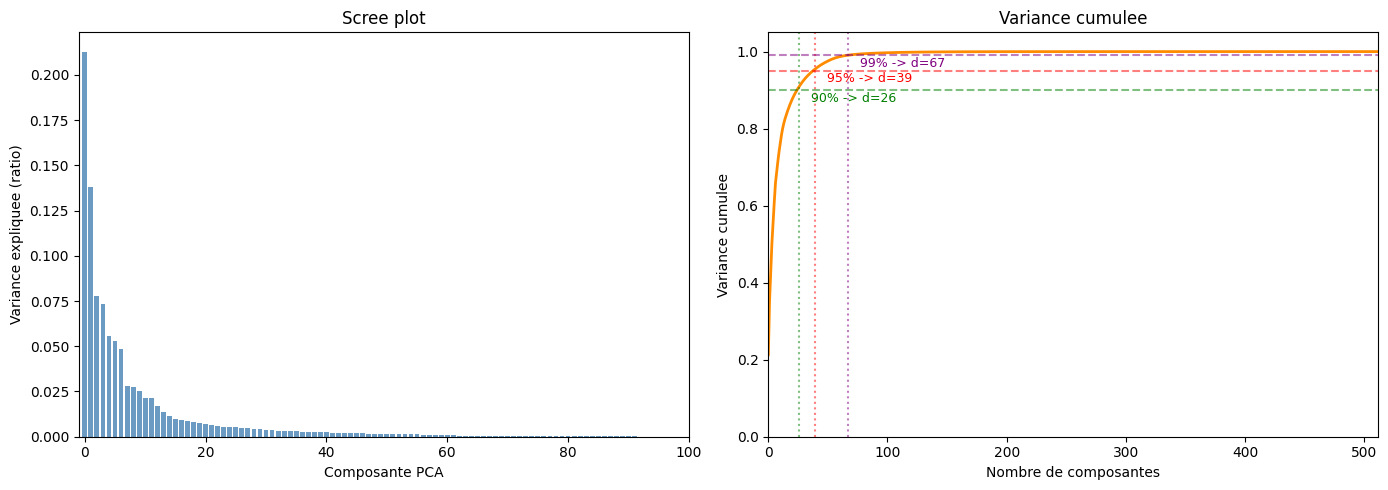

In [ ]:

# ══════════════════════════════════════════════════════════════
#  Scree plot + Variance cumulee
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scree plot (variance individuelle) ───────────────────────
ax = axes[0]
n_show = min(100, len(var_ratio))
ax.bar(range(n_show), var_ratio[:n_show], color='steelblue', alpha=0.8)
ax.set_xlabel("Composante PCA")
ax.set_ylabel("Variance expliquee (ratio)")
ax.set_title("Scree plot")
ax.set_xlim(-1, n_show)

# ── Variance cumulee ─────────────────────────────────────────
ax = axes[1]
ax.plot(cum_var, color='darkorange', linewidth=2)
for thresh, col in [(0.90, 'green'), (0.95, 'red'), (0.99, 'purple')]:
    d = np.searchsorted(cum_var, thresh) + 1
    ax.axhline(thresh, color=col, linestyle='--', alpha=0.5)
    ax.axvline(d, color=col, linestyle=':', alpha=0.5)
    ax.annotate(f"{thresh*100:.0f}% -> d={d}", xy=(d, thresh),
                xytext=(d + 10, thresh - 0.03),
                fontsize=9, color=col)
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance cumulee")
ax.set_title("Variance cumulee")
ax.set_xlim(0, len(cum_var))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


In [ ]:

# ══════════════════════════════════════════════════════════════
#  Plot — Accuracy vs nombre de composantes PCA
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results_pca[:, 0], results_pca[:, 1],
        marker='o', label='PCA', color='steelblue', linewidth=2, markersize=7)
ax.plot(results_wht[:, 0], results_wht[:, 1],
        marker='s', label='Whitened', color='darkorange', linewidth=2, markersize=7)

# annoter le meilleur de chaque
for res, col in [(results_pca, 'steelblue'), (results_wht, 'darkorange')]:
    best_idx = np.argmax(res[:, 1])
    ax.annotate(f"{res[best_idx, 1]:.3f}",
                xy=(res[best_idx, 0], res[best_idx, 1]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=col, fontweight='bold')

ax.set_xlabel("Nombre de composantes PCA (d)")
ax.set_ylabel("Accuracy (val)")
ax.set_title("CKN + SVM : impact de la reduction PCA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# ══════════════════════════════════════════════════════════════
#  Visualisation 2D — Scatter PCA colore par classe
#
#  Input : Ftr_ckn_sc, mean_tr, Vt, var_ratio, Y_train
# ══════════════════════════════════════════════════════════════

Ftr_2d = (Ftr_ckn_sc - mean_tr) @ Vt[:2].T

cmap = plt.cm.tab10
class_names = [f"Classe {i}" for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(10):
    mask = (Y_train == c)
    ax.scatter(Ftr_2d[mask, 0], Ftr_2d[mask, 1],
               c=[cmap(c)], label=class_names[c],
               s=12, alpha=0.5, edgecolors='none')

ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}% var)")
ax.set_title("CKN features — projection PCA 2D")
ax.legend(markerscale=3, fontsize=8, loc='best')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


On note qu'on a essayé des méthodes d'entraînement du CKN avec backpropagation codé entièrement avec numpy, cependant ça prenait excessivement trop de temps et nos résultats suggéraient une erreur dans sa conception. Nous avons donc décidé d'arrêter cette piste par manque de temps. Ci dessous un example de l'évolution de l'accuracy avec les epochs avec cette méthode, on observe des résultats bien moindre.

In [ ]:
# ════════════════════════════════════════════════════════════════
# LANCE L'ENTRAÎNEMENT
# ════════════════════════════════════════════════════════════════
X_train, Y_train, X_val, Y_val = train_val_split(Xtr, Ytr, val_frac=0.2, seed=42)
X_train_hwc  = to_hwc(X_train)
X_val_hwc = to_hwc(X_val)

ckn, clf = train_ckn(
    X_train_hwc, Y_train,
    X_val_hwc,   Y_val,
    n_anchors  = 128,
    pool_size  = 15,
    sigma      = 0.6,
    lr_ckn_max   = 1e-2,    # ×10 vs avant
    lr_clf_max   = 5e-2,    # ×5 vs avant
    n_epochs   = 150,
    batch_size = 128,
    weight_decay = 1e-2,
    seed       = 42
)

Init ancres par k-means...
Ancres : (128, 27)
Feature dim : 512


Entraînement:   7%|▋         | 10/150 [02:58<1:15:29, 32.35s/it]

Epoch  10 | loss 2.0974 | train 39.6% | val 37.5% | lr_ckn 0.01000


Entraînement:  13%|█▎        | 20/150 [05:50<1:05:47, 30.37s/it]

Epoch  20 | loss 1.9379 | train 43.1% | val 41.3% | lr_ckn 0.00987


...

Epoch 120 | loss 1.8317 | train 50.4% | val 47.4% | lr_ckn 0.00110


Entraînement:  87%|████████▋ | 130/150 [39:45<09:00, 27.03s/it]

Epoch 130 | loss 1.8292 | train 49.6% | val 48.1% | lr_ckn 0.00050


Entraînement:  91%|█████████ | 136/150 [40:50<04:12, 18.02s/it]


KeyboardInterrupt: 